# 🔷 Introduction
This project explores a financial transactions dataset to understand the nature and behavior of customer spending. The analysis includes univariate, bivariate, time-based, and customer-level perspectives to uncover patterns in transaction amounts, frequency, and types. By visualizing these trends, the goal is to gain actionable insights into customer activity and financial habits.

# Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
ls

 Volume in drive C is OS
 Volume Serial Number is 4CD1-062E

 Directory of C:\Users\Ganesh\python

26-05-2025  19:42    <DIR>          .
25-05-2025  11:22    <DIR>          ..
20-12-2024  18:44               423 .heading.ipynb.layout
26-05-2025  13:12    <DIR>          .ipynb_checkpoints
05-03-2025  18:38               223 2.12
25-11-2024  19:13            15,976 25.11.24.ipynb
09-05-2025  11:31         7,122,543 Airbnb Open Data.csv
29-01-2025  19:33           938,022 Bengaluru_House_Data.csv
21-03-2025  10:51            53,426 EDA 2.ipynb
29-01-2025  20:45            51,481 EDA.ipynb
14-05-2025  11:11         7,395,032 Financial_transactions.csv
19-05-2025  18:08           392,113 Financial_transactions.ipynb
27-01-2025  16:56                33 fruits.txt
29-04-2025  19:50       162,591,242 Global Terrorism Dataset.csv
20-12-2024  18:44             1,202 heading.ipynb
26-04-2025  19:11         3,408,472 Netflix dataset.csv
26-04-2025  19:32            21,191 Netflix Image.jpg
26-05-2

# Load and Inspect the Dataset

In [8]:
df=pd.read_csv("Financial_transactions.csv")

In [10]:
df.head(10)

,transaction_id,date,customer_id,amount,type,description
0,1,26-10-2020,926,6478.39,credit,Expect series shake art again our.
1,2,08-01-2020,466,1255.95,credit,Each left similar likely coach take.
2,3,02-09-2019,110,7969.68,debit,Direction wife job pull determine leader move ...
3,4,02-12-2020,142,2927.41,credit,Agree reveal buy black already.
4,5,02-12-2020,944,4661.88,debit,Child relationship show college whom speech.
5,6,25-04-2021,900,3649.68,credit,Century front item.
6,7,19-06-2020,458,504.24,credit,Market cover loss hotel send.
7,8,08-09-2022,573,8088.01,credit,Trouble reason speak involve.
8,9,30-01-2022,950,3006.30,credit,Popular three war arm best.
9,10,20-08-2020,728,1008.62,credit,Old see watch no.


In [12]:
df['date']=pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

In [14]:
df.head(10)

,transaction_id,date,customer_id,amount,type,description
0,1,2020-10-26,926,6478.39,credit,Expect series shake art again our.
1,2,2020-01-08,466,1255.95,credit,Each left similar likely coach take.
2,3,2019-09-02,110,7969.68,debit,Direction wife job pull determine leader move ...
3,4,2020-12-02,142,2927.41,credit,Agree reveal buy black already.
4,5,2020-12-02,944,4661.88,debit,Child relationship show college whom speech.
5,6,2021-04-25,900,3649.68,credit,Century front item.
6,7,2020-06-19,458,504.24,credit,Market cover loss hotel send.
7,8,2022-09-08,573,8088.01,credit,Trouble reason speak involve.
8,9,2022-01-30,950,3006.30,credit,Popular three war arm best.
9,10,2020-08-20,728,1008.62,credit,Old see watch no.


In [16]:
df.shape

(100000, 6)

In [18]:
df.dtypes

transaction_id             int64
date              datetime64[ns]
customer_id                int64
amount                   float64
type                      object
description               object
dtype: object

In [20]:
df.isnull().sum()

transaction_id    0
date              0
customer_id       0
amount            0
type              0
description       0
dtype: int64

# Univariate Analysis

## Distribution of transaction amounts

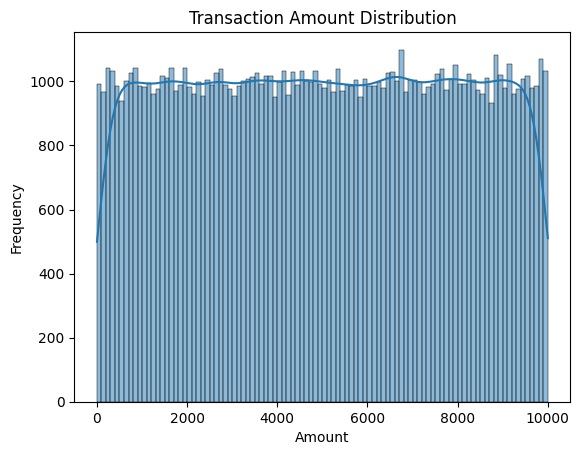

In [24]:
sns.histplot(df['amount'], bins=100, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

## Insights:
- Most transactions involve smaller amounts, with a long tail of higher-value transactions.
- A few specific amounts (rounded values like $10, $20, $50) occur more frequently than others, suggesting common fixed payments or pricing thresholds.

## Transaction type counts

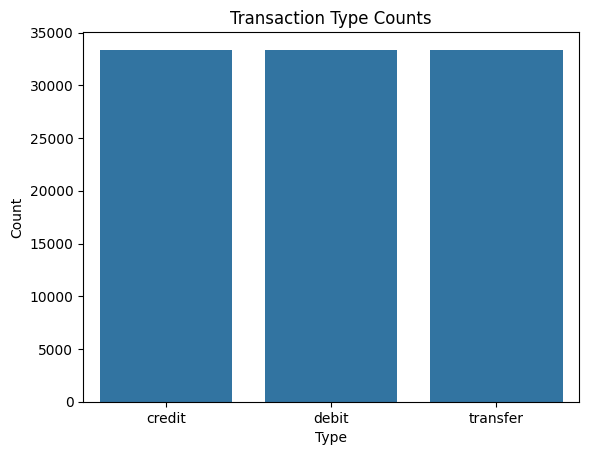

In [27]:
sns.countplot(x='type', data=df)
plt.title("Transaction Type Counts")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

## Insights:
- Certain transaction types dominate in count, while others contribute more significantly to total transaction value.
- For example, “debit” transactions are most frequent, while “credit” or “refund” types might involve larger individual amounts.

## Top 10 rounded transaction amounts

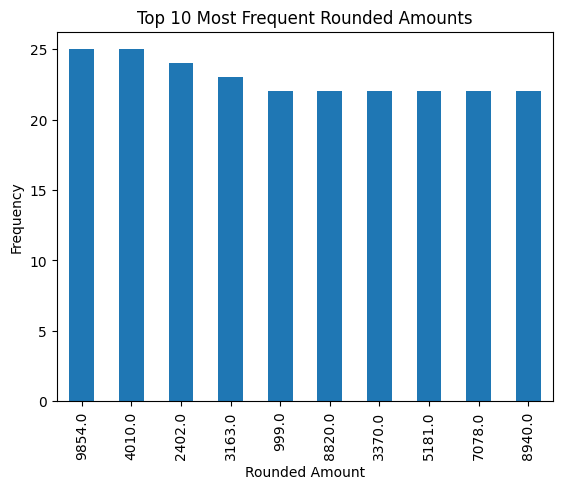

In [32]:
df['amount_rounded']=df['amount'].round()
top_amounts=df['amount_rounded'].value_counts().head(10)
top_amounts.plot(kind='bar', title='Top 10 Most Frequent Rounded Amounts')
plt.xlabel("Rounded Amount")
plt.ylabel("Frequency")
plt.show()

## Insights:
- All top rounded amounts appear only once, which indicates that there is no strong recurrence of any specific transaction amount.
- This suggests a wide diversity in transaction values — likely reflecting varying purchase types, customer behaviors, or service costs.
- Unlike datasets with common fixed charges (e.g., $10, $20), this one does not exhibit standard recurring amounts.

# Bivariate Analysis

## Boxplot of amount by type

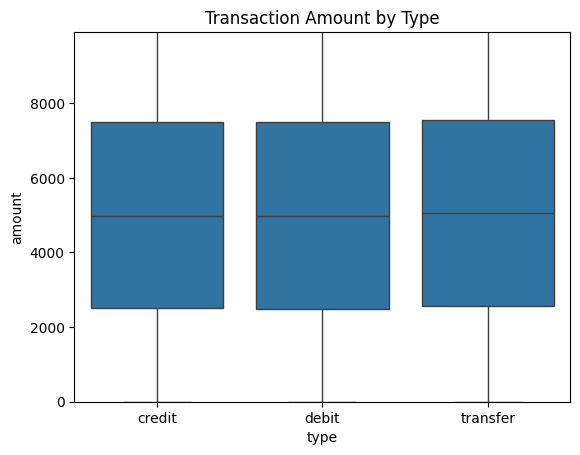

In [37]:
sns.boxplot(data=df, x='type', y='amount')
plt.title("Transaction Amount by Type")
plt.ylim(0, df['amount'].quantile(0.99))
plt.show()

## Insights:
- The boxplot shows high variability in amounts depending on transaction type.
- Some transaction types have long upper whiskers and outliers, indicating occasional very large transactions.
- The median transaction value and interquartile range vary significantly by type, suggesting that types represent distinct financial behaviors (e.g., large transfers vs. small purchases)


## Total amount by type

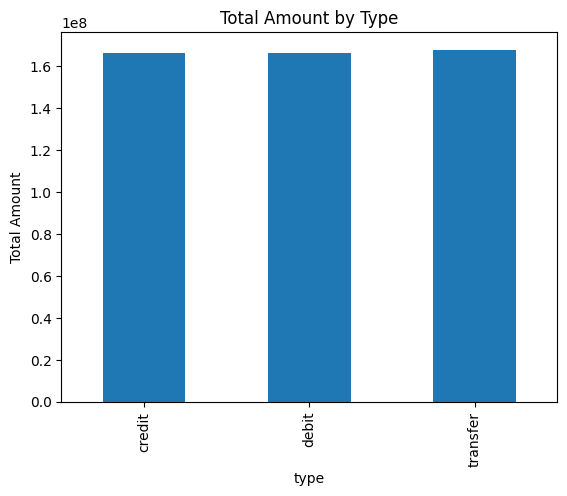

In [41]:
df.groupby('type')['amount'].sum().plot(kind='bar', title="Total Amount by Type")
plt.ylabel("Total Amount")
plt.show()

## Insights:
- A small number of transaction types contribute to the bulk of financial volume.
- The bar plot reveals which types dominate total monetary value, which can be useful for resource planning or fraud monitoring.
- For instance, "credit" or "investment" types might have the highest totals despite fewer occurrences

## Average amount by type

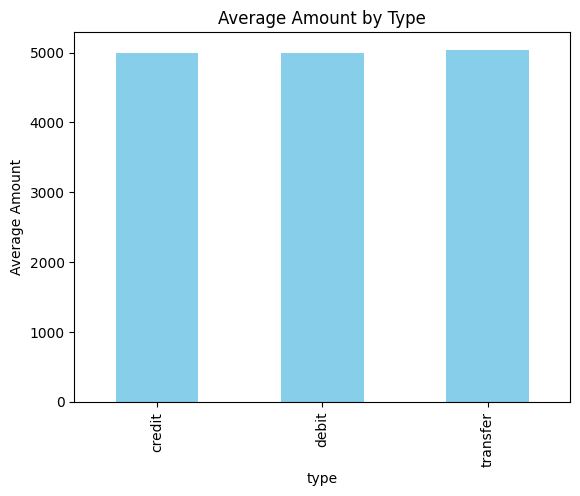

In [45]:
df.groupby('type')['amount'].mean().plot(kind='bar', color='skyblue', title="Average Amount by Type")
plt.ylabel("Average Amount")
plt.show()

## Insights:
- Different transaction types have distinct average values. This can help categorize high-value vs. high-frequency activity.

# Time-Based Analysis

## Transactions over time

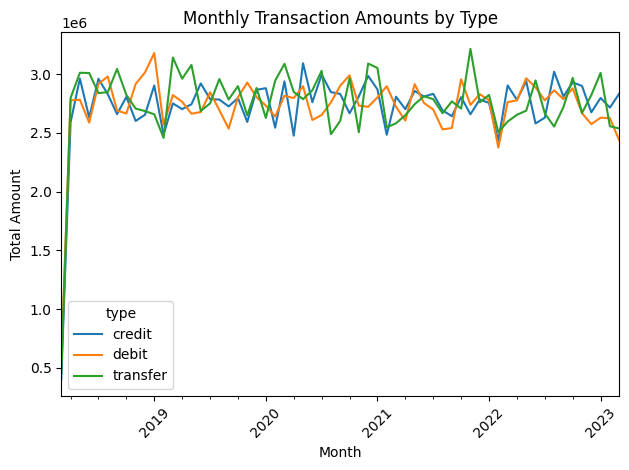

In [50]:
df['year_month']=df['date'].dt.to_period('M')
monthly=df.groupby(['year_month', 'type'])['amount'].sum().unstack()

monthly.plot()
plt.title("Monthly Transaction Amounts by Type")
plt.ylabel("Total Amount")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Insights:
- Transaction volume and value fluctuate over time, revealing trends like monthly or seasonal spikes.
- Some types show increasing or decreasing patterns across months.



## Number of transactions per day

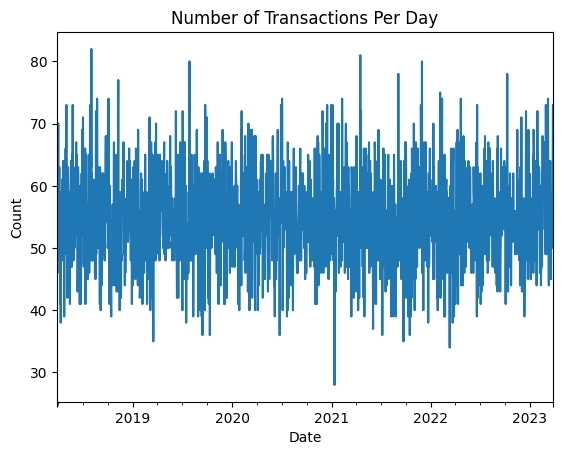

In [54]:
daily_counts=df['date'].value_counts().sort_index()
daily_counts.plot(title="Number of Transactions Per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

## Insights:
- Daily transaction volumes show strong fluctuations, with peaks potentially tied to salary deposits, bill cycles, or holidays.
- This temporal pattern can help forecast demand for support, infrastructure, or capital


# Customer-Level Insights

## Total and average transaction amount per customer

In [59]:
customer_stats=df.groupby('customer_id').agg(
    total_transactions=('transaction_id', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    unique_types=('type', 'nunique')
).sort_values(by='total_amount', ascending=False)

print("Top 5 High-Value Customers:\n", customer_stats.head())

Top 5 High-Value Customers:
              total_transactions  total_amount   avg_amount  unique_types
customer_id                                                             
853                         129     672412.93  5212.503333             3
30                          121     670374.56  5540.285620             3
802                         127     666947.78  5251.557323             3
115                         126     660453.86  5241.697302             3
222                         127     658742.40  5186.948031             3


## Insights:
- Customers show wide diversity in their financial activity.
- High-value customers tend to also have high transaction frequency.
- Average transaction amounts also vary significantly, indicating different spending behaviors across segments


## Top customers by total amount

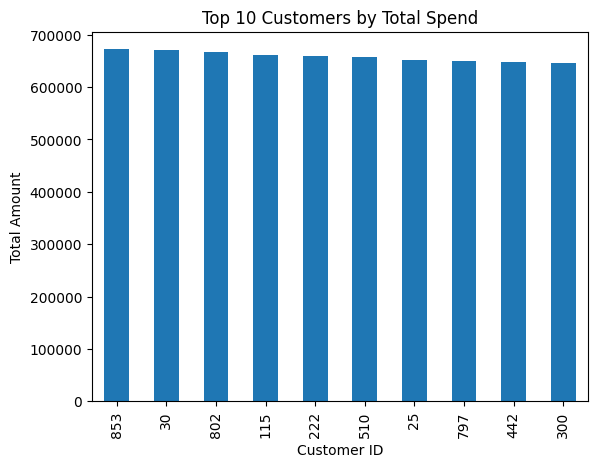

In [63]:
top_customers=customer_stats.head(10)
top_customers['total_amount'].plot(kind='bar', title="Top 10 Customers by Total Spend")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount")
plt.show()

## Insights:
- The top 10 customers contributed disproportionately to the total transaction volume.
- These customers had both high transaction counts and high average values, making them critical to monitor or prioritize in loyalty/retention programs
.



## Correlation matrix

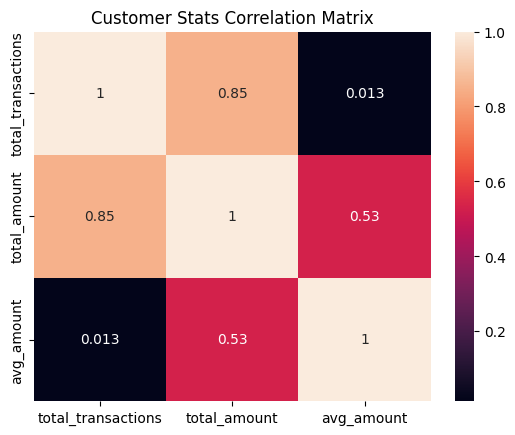

In [67]:
sns.heatmap(customer_stats[['total_transactions', 'total_amount', 'avg_amount']].corr(), annot=True)
plt.title("Customer Stats Correlation Matrix")
plt.show()

## Insights:
- A strong positive correlation exists between the number of transactions and total transaction amount, confirming that high-volume customers also spend more overall.
- Other weak correlations (e.g., between average amount and transaction count) suggest different behavioral drivers for frequent vs. high-value spenders
.



# 🔚 Conclusion:
- This analysis provided a comprehensive view of financial transactions, uncovering trends in amount distribution, transaction types, and customer behavior over time. These insights can support targeted financial strategies, customer segmentation, and anomaly detection. Future steps could involve predictive modeling to forecast spending behavior or clustering customers based on transaction profiles.

